In [1]:
# o

The `merge_images()` function merges the images of the two directories into a new one. If it is already done, it simply returns `None`:

In [2]:
from pathlib import Path

from data.images import merge_images
from ham_clf.utils.loggers import HAMLogger

logconf_path = Path.cwd().parent.parent / "conf" / "logconf.yaml"
ROOT = Path.cwd().parent.parent
merged_directory = ROOT / "images" / "HAM10000_images_full"

logger = HAMLogger()
log = logger.configure_from_file(filepath=logconf_path)
merge_images(merged_directory=merged_directory, log=log)

[INFO]:
HAM10000_images_full already exists


This custom class preprocesses the dataset given it's filepath. It firstly drops duplicate images on the same lesion, splits on a *train_size_split* -which can be set by the user- and handles the data imbalance *only* on the training set by oversampling/undersampling based on a fixed *target_samples_per_class*. After making sure there is a unique image per lesion on the splitted sets, it returns them using the `.preprocess()` method. On training we'll use also *class_weights*:

In [3]:
import json

from data.preprocessing import HAMDataProcessor

filepath = merged_directory.with_name("HAM10000_metadata.csv")
processor = HAMDataProcessor(filepath=filepath, log=log)
train_df, valid_df, test_df = processor.preprocess()

log.info(json.dumps(processor.target_samples_per_class, indent=3))
log.info(f"train_size_split: {processor.train_size_split}")
log.info(f"records_per_dataframe: {[len(df_) for df_ in (train_df, valid_df, test_df)]}")

[INFO]:
{
   "melanocytic_nevi": 2500,
   "melanoma": 1113,
   "benign_keratosis": 1100,
   "basal_cell_carcinoma": 900,
   "actinic_keratoses": 600,
   "vascular_lesions": 300,
   "dermatofibroma": 300
}
[INFO]:
train_size_split: 0.7
[INFO]:
records_per_dataframe: [6813, 1121, 1121]


Plot some random images using the *image_id* column of the training dataframe with an utility function:

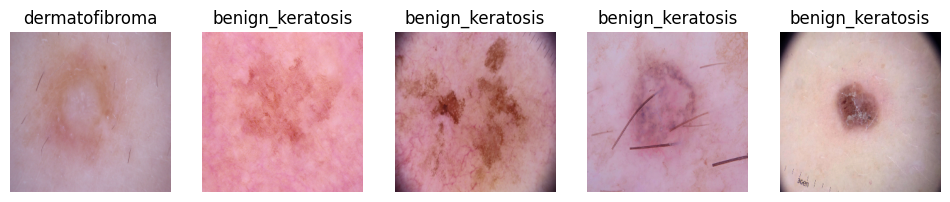

In [4]:
import matplotlib.pyplot as plt

from data.images import plot_random_image

plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plot_random_image(df=train_df, images_dir=merged_directory, size=(256, 256))

This class gets initialized using the preprossed training dataframe only, where we extract the class names. The *size* of the images and *batch_size* can be both set by the user, defaulting to **[224, 224]** and **16** since we'll be using the ``MobileNetV2`` model and train on CPU by freezing it's original weights. The *data_augmentation* is simply a `keras.Sequential` model performing some random transformations. As we can see this is an attemp to reproduce the `ImageDataGenerator` class, which was depricated. The `.flow_from_dataframe()` method returns shuffled (or not), batched `tf.data.Dataset`, which are mapped using the methods `._load_and_preprocess()` and `._apply_augmentation()`:

In [5]:
from data.generators import HAMDataGenerator

data_generator = HAMDataGenerator(train_df=train_df)

log.info(f"classes: {', '.join(data_generator.classes)}")
log.info(f"target_image_size: {data_generator.size}")
log.info(f"batch_size: {data_generator.batch_size}")
log.info(f"augmentation_model: {data_generator.data_augmentation}")

[INFO]:
classes: actinic_keratoses, basal_cell_carcinoma, benign_keratosis, dermatofibroma, melanocytic_nevi, melanoma, vascular_lesions
[INFO]:
target_image_size: [224, 224]
[INFO]:
batch_size: 16


[INFO]:
augmentation_model: <Sequential name=augmentation, built=False>


In [6]:
train_ds = data_generator.flow_from_dataframe(
    df=train_df, directory=merged_directory, x_col="image_id", y_col="dx", shuffle=True
)

valid_ds = data_generator.flow_from_dataframe(df=valid_df, directory=merged_directory, x_col="image_id", y_col="dx")

test_ds = data_generator.flow_from_dataframe(df=test_df, directory=merged_directory, x_col="image_id", y_col="dx")

Let's view the first batch of the training set:

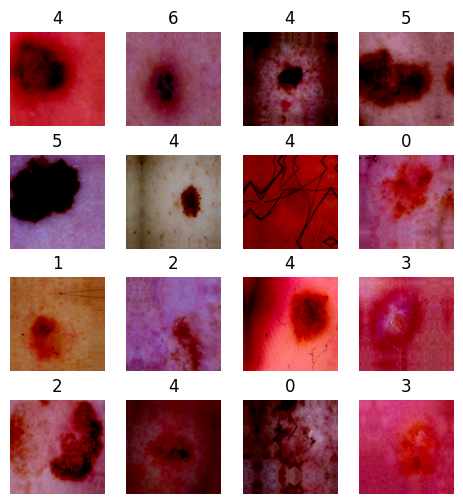

In [7]:
for X_batch, y_batch in train_ds.take(1).as_numpy_iterator():
    plt.figure(figsize=(6, 6))
    for idx, image in enumerate(X_batch):
        plt.subplot(4, 4, idx + 1)
        plt.imshow(image)
        plt.title(y_batch.argmax(axis=1)[idx])
        plt.axis("off")
plt.subplots_adjust(wspace=0, hspace=0.3)

Compute the *class_weight_dict* using internally sklearns' `compute_class_weight()` function:

In [8]:
from ham_clf.utils.weights import get_class_weight_dict

classes = data_generator.classes
y = train_df.dx.astype(str).to_numpy()
class_weight_dict = get_class_weight_dict(classes=classes, y=y)
log.info(json.dumps(class_weight_dict, indent=3))

[INFO]:
{
   "0": 1.622142857142857,
   "1": 1.0814285714285714,
   "2": 0.8848051948051948,
   "3": 3.244285714285714,
   "4": 0.3893142857142857,
   "5": 0.8744705429341548,
   "6": 3.244285714285714
}


Let's view our configuration which will be used in training stage. Note that on the fine tuning stage we need a resolver:

In [9]:
from omegaconf import OmegaConf

config_path = logconf_path.with_name("config.yaml")
cfg = OmegaConf.load(config_path)
OmegaConf.register_new_resolver(name="lower_lr", resolver=lambda lr: 0.1 * lr)
log.info(json.dumps(OmegaConf.to_object(cfg), indent=3))

[INFO]:
{
   "dataset": {
      "csv": "HAM10000_metadata.csv",
      "dirname": "HAM10000_images_full"
   },
   "training": {
      "transfer": {
         "input_shape": [
            224,
            224,
            3
         ],
         "weights": "imagenet",
         "learning_rate": 0.001,
         "alpha": 0.75,
         "units": 128,
         "n_classes": 7,
         "dropout_rate": 0.5,
         "epochs": 10
      },
      "fine_tuning": {
         "n_last_layers": 30,
         "learning_rate": 0.0001,
         "epochs": 10,
         "modelname": "mobilenetv2_ft0.keras"
      }
   }
}


Training happens in two stages: transfer learning and fine tuning. It's configurable using the **conf/config.yaml** file:

In [ ]:
from ham_clf.model.build import MobileNetV2FT0

mobilenet_ft = MobileNetV2FT0(config=cfg)
history_tl = mobilenet_ft.transfer(
    train_ds=train_ds, valid_ds=valid_ds, class_weight_dict=class_weight_dict, callbacks=[]
)

Epoch 1/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 97s 221ms/step - categorical_accuracy: 0.3923 - loss: 1.5180 - val_categorical_accuracy: 0.4398 - val_loss: 1.3227
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 91s 214ms/step - categorical_accuracy: 0.4741 - loss: 1.2507 - val_categorical_accuracy: 0.6450 - val_loss: 1.0070
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 90s 210ms/step - categorical_accuracy: 0.5054 - loss: 1.1412 - val_categorical_accuracy: 0.5816 - val_loss: 1.1147
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 90s 210ms/step - categorical_accuracy: 0.5347 - loss: 1.0523 - val_categorical_accuracy: 0.6244 - val_loss: 0.9512
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 94s 220ms/step - categorical_accuracy: 0.5466 - loss: 1.0299 - val_categorical_accuracy: 0.6057 - val_loss: 1.0466
Epoch 6/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 93s 218ms/step - categorical_accuracy: 0.5525 - loss: 0.9917 - val_categorical_accuracy: 0.5932 - val_loss: 1.0504
Epoch 7/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 92s 216ms/step - categorical_a

In [11]:
mobilenet_ft.model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        648 │ input_layer_1[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         96 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        216 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         96 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        384 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 1,876,679 (7.16 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 1,382,064 (5.27 MB)

 Optimizer params: 329,744 (1.26 MB)

In [ ]:
import tensorflow as tf

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history_ft = mobilenet_ft.fine_tune(
    train_ds=train_ds, valid_ds=valid_ds, class_weight_dict=class_weight_dict, callbacks=[early_stopping_cb]
)